## handwritten digit recognition 



### impoprting

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


importing data

In [3]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

preprocessing


In [4]:
# here we are just normalising the data and only the x not the variables 
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

now comes the model

In [8]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape = (28,28)))  # it converts 2d array to 1d array
model.add(tf.keras.layers.Dense(128, activation = 'relu'))
model.add(tf.keras.layers.Dense(128, activation = 'relu'))
model.add(tf.keras.layers.Dense(10, activation = 'softmax'))  # 10 because we have 10 digits from 0 to 9

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
model.fit(x_train, y_train, epochs = 3)
model.save('handwritten.keras')

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9240 - loss: 0.2599
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9667 - loss: 0.1082
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9772 - loss: 0.0736


In [9]:
loss , accuracy = model.evaluate(x_test, y_test)
print(loss)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9741 - loss: 0.0869
0.08691384643316269
0.9740999937057495


now with our own images


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
the prediction for image 1 is 2


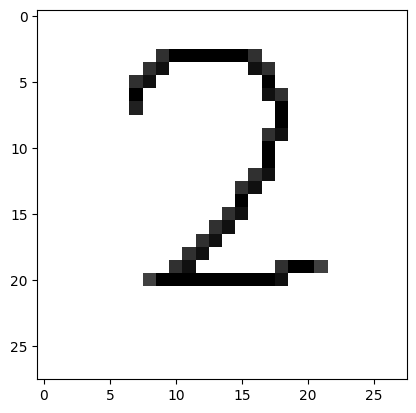

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
the prediction for image 2 is 2


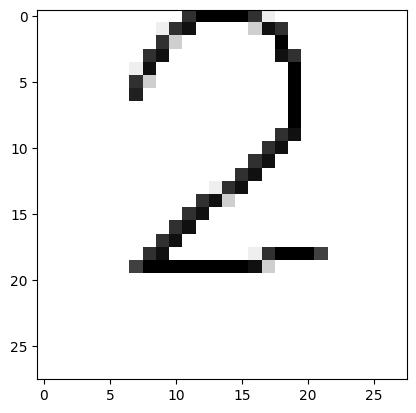

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
the prediction for image 3 is 6


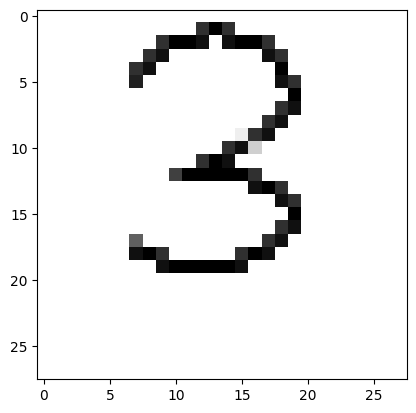

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
the prediction for image 4 is 5


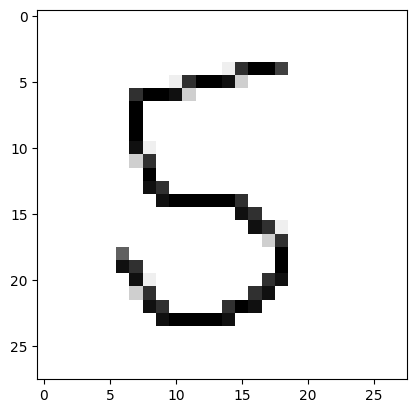

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
the prediction for image 5 is 6


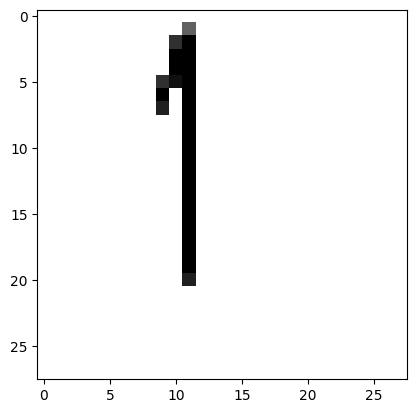

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
the prediction for image 6 is 1


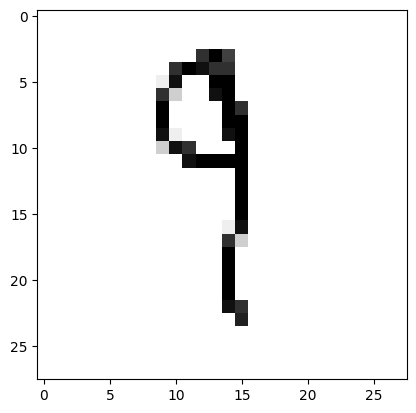

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
the prediction for image 7 is 6


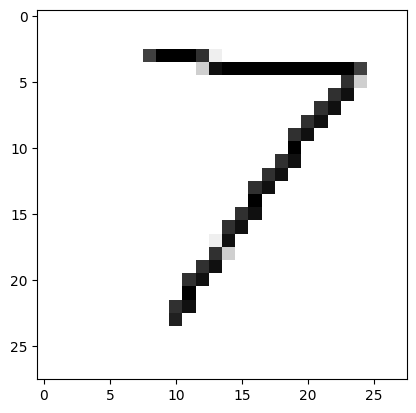

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
the prediction for image 8 is 0


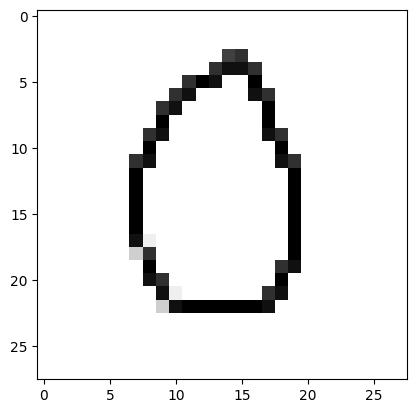

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
the prediction for image 9 is 9


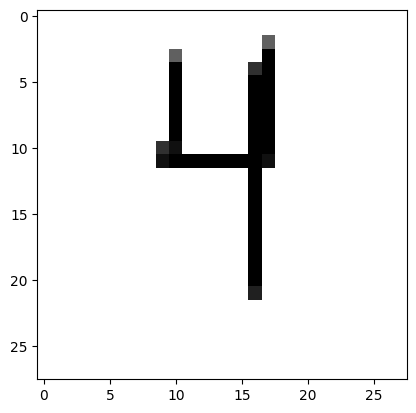

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
the prediction for image 10 is 6


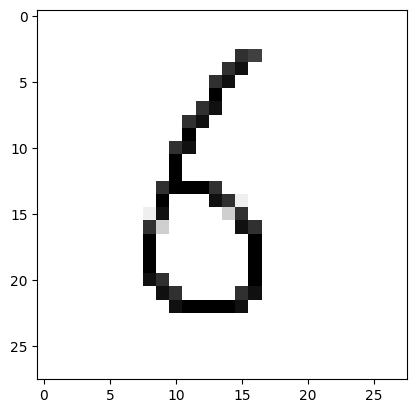

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
the prediction for image 11 is 8


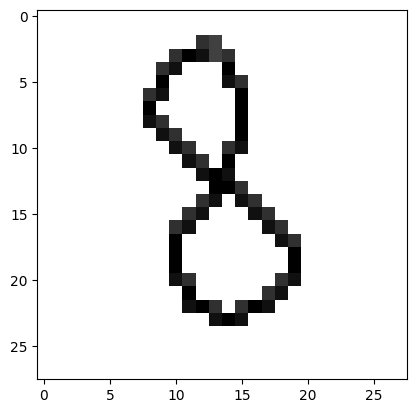

In [10]:
i = 1
while os.path.isfile(f"test images/{i}.png"):
    img = cv2.imread(f"test images/{i}.png")[:,:,0]
    img = np.invert(np.array([img]))
    prediction = model.predict(img)
    print(f"the prediction for image {i} is {np.argmax(prediction)}")
    plt.imshow(img[0], cmap=plt.cm.binary)
    plt.show()
    i += 1
    